# 02 - Distance to Policy Calculation

## Overview
- Calculate citation distance from policy-cited papers (via references / citedby)
- Visualize distance distribution by Scopus clusters

## Outputs
- `tmp/distances_to_policy_ref.pickle` - Distance via references only
- `tmp/distances_to_policy_both.pickle` - Distance via references + citedby
- `output/figures/fig_distance_to_policy.eps` - Distance distribution figure
- `output/figures/fig_distance_to_policy_cumulative.eps` - Cumulative distribution figure

In [8]:
# === Setup ===
import sys
sys.path.append('..')

from config.settings import (
    TmpPaths, OutputPaths, SCOPUS_BASE
)
from src.utils import flatten
from src.data_loader import load_pickle, save_pickle

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scienceplots

%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.style.use('science')
warnings.filterwarnings('ignore')

---
## 1. Load Data

In [10]:
policy_cited_scopus = load_pickle(TmpPaths.POLICY_CITED_PAPER)
print(f"Policy cited papers: {len(policy_cited_scopus)}")

Policy cited papers: 230737


In [11]:
papers = pd.concat([
    load_pickle(SCOPUS_BASE / 'paper' / 'year.pickle'),
    load_pickle(SCOPUS_BASE / 'clustering' / 'leiden_CPM' / 'partition_res_1e-07_margedto_6.pickle'),
], axis=1)
print(f"All papers: {len(papers)}")

All papers: 91863964


In [12]:
references = load_pickle(SCOPUS_BASE / 'citation' / 'reference.pickle')
citedby = load_pickle(SCOPUS_BASE / 'citation' / 'citedby.pickle')
print(f"References: {len(references)}, Citedby: {len(citedby)}")

References: 70394880, Citedby: 65116934


In [13]:
cluster_info = load_pickle(SCOPUS_BASE / 'clustering' / 'leiden_CPM' / 'partition_res_1e-07_info.pickle')
papers['cluster'] = load_pickle(SCOPUS_BASE / 'clustering' / 'leiden_CPM' / 'partition_res_1e-07_margedto_6.pickle')

---
## 2. Distance Calculation (Reference Only)

In [14]:
cutoff = 2023
target_papers = set(papers.query('year<=@cutoff').index)

distances = {}
distances[0] = set(policy_cited_scopus.query('year<=@cutoff').index) & target_papers
inds = set(references.index) & target_papers

for i in range(1, 21):
    tmp = set(flatten(references.loc[list(distances[i-1] & inds)]))
    distances[i] = tmp
    print(f"{i}: {len(distances[i])} (raw)")
    
    for j in range(0, i):
        distances[i] -= distances[j]
    print(f"{i}: {len(distances[i])} (after dedup)")

1: 3626350 (raw)
1: 3476325 (after dedup)
2: 18139263 (raw)
2: 14922293 (after dedup)
3: 32263402 (raw)
3: 15663470 (after dedup)
4: 35033426 (raw)
4: 7514831 (after dedup)
5: 28420535 (raw)
5: 3163972 (after dedup)
6: 19380838 (raw)
6: 1402889 (after dedup)
7: 12097101 (raw)
7: 657046 (after dedup)
8: 7051454 (raw)
8: 316467 (after dedup)
9: 3852005 (raw)
9: 153042 (after dedup)
10: 1970946 (raw)
10: 74144 (after dedup)
11: 1000645 (raw)
11: 35878 (after dedup)
12: 487230 (raw)
12: 17975 (after dedup)
13: 243301 (raw)
13: 9317 (after dedup)
14: 125575 (raw)
14: 5195 (after dedup)
15: 80765 (raw)
15: 3347 (after dedup)
16: 56379 (raw)
16: 2267 (after dedup)
17: 43741 (raw)
17: 1617 (after dedup)
18: 28328 (raw)
18: 938 (after dedup)
19: 17036 (raw)
19: 584 (after dedup)
20: 10573 (raw)
20: 311 (after dedup)


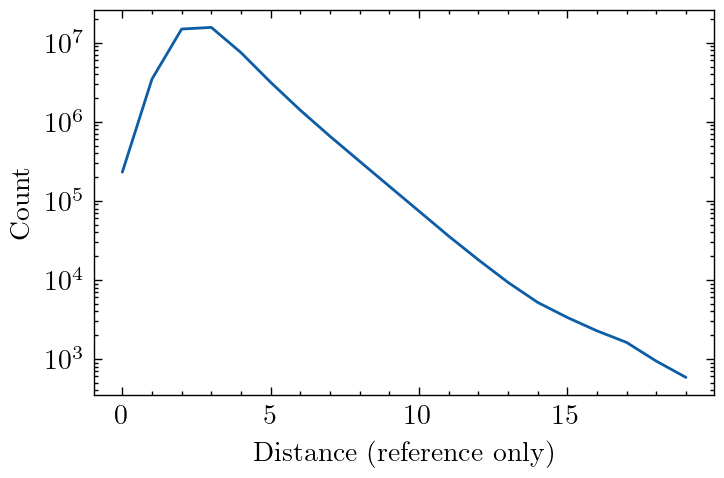

In [15]:
for i in range(0, 20):
    papers.loc[list(set(distances[i]) & set(papers.index)), 'distance_ref'] = i

ax = papers.query('distance_ref>=0').distance_ref.value_counts().sort_index().plot()
ax.set_yscale('log')
ax.set_xlabel('Distance (reference only)')
ax.set_ylabel('Count')
plt.show()

In [16]:
save_pickle(papers.distance_ref, TmpPaths.DISTANCE_REF)
print(f"Saved: {TmpPaths.DISTANCE_REF}")

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/distances_to_policy_ref.pickle
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/distances_to_policy_ref.pickle


---
## 3. Distance Calculation (Reference + Citedby)

In [17]:
cutoff = 2023
target_papers = set(papers.query('year<=@cutoff').index)

distances = {}
distances[0] = set(policy_cited_scopus.query('year<=@cutoff').index) & target_papers
inds = set(references.index) & target_papers
inds2 = set(citedby.index) & target_papers

for i in range(1, 11):
    tmp = set(flatten(references.loc[list(distances[i-1] & inds)]))
    tmp2 = set(flatten(citedby.loc[list(distances[i-1] & inds2)]))
    distances[i] = tmp | tmp2
    print(f"{i}: {len(distances[i])} (raw)")
    
    for j in range(0, i):
        distances[i] -= distances[j]
    print(f"{i}: {len(distances[i])} (after dedup)")

1: 9636852 (raw)
1: 9436320 (after dedup)
2: 54498476 (raw)
2: 44892416 (after dedup)
3: 74718435 (raw)
3: 21569627 (after dedup)
4: 45496823 (raw)
4: 2879087 (after dedup)
5: 5329266 (raw)
5: 285562 (after dedup)
6: 392541 (raw)
6: 39706 (after dedup)
7: 47025 (raw)
7: 8073 (after dedup)
8: 9230 (raw)
8: 1999 (after dedup)
9: 2359 (raw)
9: 555 (after dedup)
10: 632 (raw)
10: 143 (after dedup)


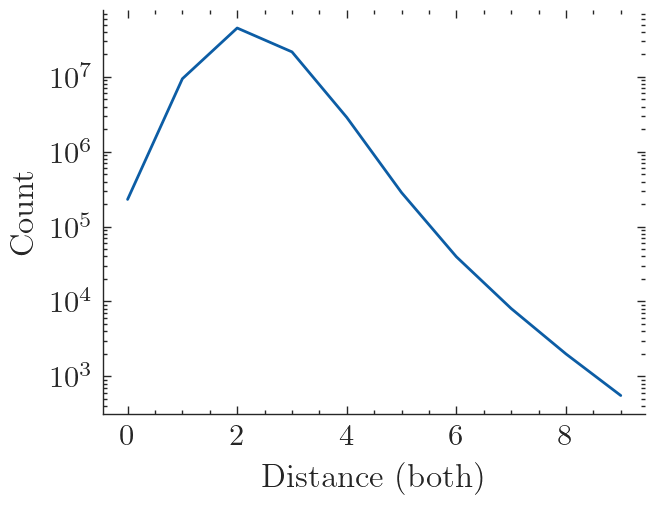

In [18]:
for i in range(0, 10):
    papers.loc[list(set(distances[i]) & set(papers.index)), 'distance'] = i

ax = papers.query('distance>=0').distance.value_counts().sort_index().plot()
ax.set_yscale('log')
ax.set_xlabel('Distance (both)')
ax.set_ylabel('Count')
plt.show()

In [19]:
save_pickle(papers.distance, TmpPaths.DISTANCE_BOTH)
print(f"Saved: {TmpPaths.DISTANCE_BOTH}")

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/distances_to_policy_both.pickle
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/distances_to_policy_both.pickle


---
## 4. Distance Distribution Visualization by Cluster

In [20]:
papers['connected'] = papers.distance.apply(lambda x: 1 if x > 0 else 0)
papers['distance'] = papers['distance'].fillna(10000)

In [21]:
partition_name = {
    0: 'Medical Science',
    1: 'Materials Science',
    2: 'Information Science',
    3: 'Social Science',
    4: 'Environmental Science',
    5: 'Physics',
}

In [22]:
plt.style.use('science')
sns.set_theme(
    style="ticks",
    rc={
        "font.family": "serif",
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.grid": False,
    },
)
plt.style.use('science')
sns.set_palette(sns.color_palette('tab10', 6))
lines = ['-', '--', ':', '-.', '--', ':']

All: distance
1.0    0.007142
2.0    0.186144
3.0    0.567410
4.0    0.155114
5.0    0.015212
Name: count, dtype: float64
Medical Science: dist<=3 = 0.931
Materials Science: dist<=3 = 0.737
Information Science: dist<=3 = 0.712
Social Science: dist<=3 = 0.832
Environmental Science: dist<=3 = 0.889
Physics: dist<=3 = 0.370


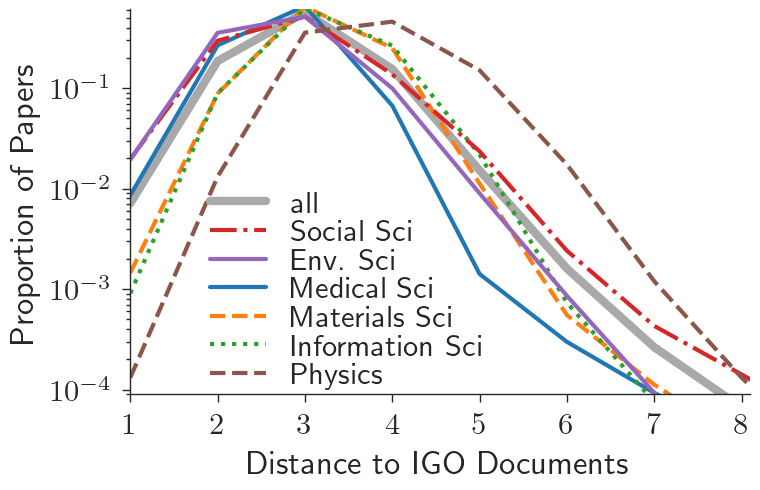

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/fig_distance_to_policy.pdf


In [26]:
# Figure: Distance to Policy (Proportion)
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5))

tmp = papers.query('year>=2015').distance.value_counts()
tmp = tmp / tmp.sum()
tmp.index = tmp.index + 1
tmp.sort_index().plot(ax=ax, label="all", linestyle=lines[0], lw=3, c='darkgray')
print("All:", tmp.sort_index()[:5])

for k, v in papers.query('year>=2015').groupby('cluster'):
    if k < 10:
        tmp = v.distance.value_counts()
        tmp = tmp / tmp.sum()
        tmp.index = tmp.index + 1
        distance3 = tmp.loc[[x for x in tmp.index if x <= 3]].sum()
        print(f"{partition_name[k]}: dist<=3 = {distance3:.3f}")
        label = partition_name[k].replace('Environmental', 'Env.').replace('Science', 'Sci')
        tmp.sort_index().plot(ax=ax, label=label, linestyle=lines[int(k % 4)], lw=1.5, alpha=1)

handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 4, 5, 1, 2, 3, 6]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='upper center', bbox_to_anchor=(0.35, 0.6), labelspacing=0.04,
           ncol=1, fancybox=False, shadow=False, handlelength=1.85)

ax.minorticks_off()
ax.set_xlim([1, 8.1])
ax.set_ylim([0.00009, 0.61])
ax.set_xticks(range(1, 9))
ax.set_xlabel('Distance to IGO Documents')
ax.set_ylabel('Proportion of Papers')
ax.set_yscale('log')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=True, bottom=False)

plt.show()

output_path = OutputPaths.FIGURES / 'fig_distance_to_policy.eps'
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path)
output_path = OutputPaths.FIGURES / 'fig_distance_to_policy.pdf'
fig.savefig(output_path)
print(f"Saved: {output_path}")

All: dist<=3 = 0.594
Medical Science: dist<=3 = 0.843
Materials Science: dist<=3 = 0.567
Information Science: dist<=3 = 0.592
Social Science: dist<=3 = 0.765
Environmental Science: dist<=3 = 0.815
Physics: dist<=3 = 0.255


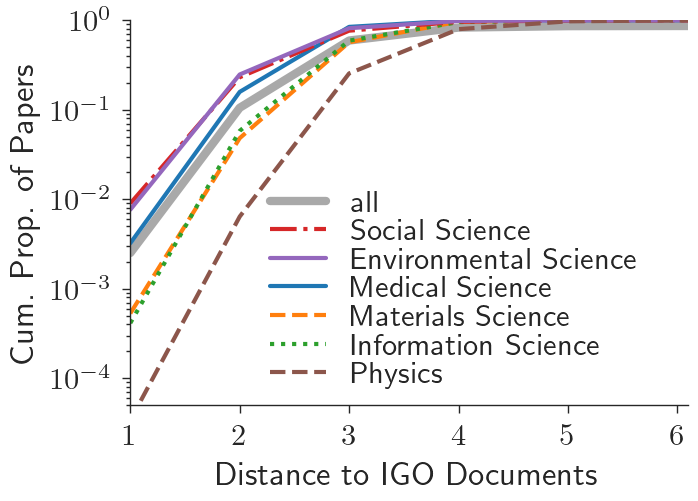

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/fig_distance_to_policy_cumulative.pdf


In [27]:
# Figure: Distance to Policy (Cumulative)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
})

fig, ax = plt.subplots(1, 1, figsize=(3.6, 2.5))

tmp = papers.distance.value_counts()
tmp = tmp / tmp.sum()
tmp.index = tmp.index + 1
tmp.sort_index().cumsum().plot(ax=ax, label="all", linestyle=lines[0], lw=3, c='darkgray')
print(f"All: dist<=3 = {tmp.loc[[x for x in tmp.index if x <= 3]].sum():.3f}")

for k, v in papers.groupby('cluster'):
    if k < 10:
        tmp = v.distance.value_counts()
        tmp = tmp / tmp.sum()
        tmp.index = tmp.index + 1
        distance3 = tmp.loc[[x for x in tmp.index if x <= 3]].sum()
        print(f"{partition_name[k]}: dist<=3 = {distance3:.3f}")
        tmp.sort_index().cumsum().plot(ax=ax, label=partition_name[k], 
                                        linestyle=lines[int(k % 4)], lw=1.5, alpha=1)

handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 4, 5, 1, 2, 3, 6]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='upper center', bbox_to_anchor=(0.58, 0.63), labelspacing=0.04,
           ncol=1, fancybox=False, shadow=False, handlelength=1.85)

ax.minorticks_off()
ax.set_xlim([1, 6.1])
ax.set_ylim([0.00005, 1.0])
ax.set_xticks(range(1, 7))
ax.set_xlabel('Distance to IGO Documents')
ax.set_ylabel('Cum. Prop. of Papers')
ax.set_yscale('log')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=True, bottom=False)

plt.show()

output_path = OutputPaths.FIGURES / 'fig_distance_to_policy_cumulative.eps'
fig.savefig(output_path)
output_path = OutputPaths.FIGURES / 'fig_distance_to_policy_cumulative.pdf'
fig.savefig(output_path)
print(f"Saved: {output_path}")

---
## 5. Policy-Connected Proportion

In [25]:
plot_df = papers.query('year<=2023').groupby('cluster')['connected'].mean()
plot_df.index = [partition_name[i] for i in plot_df.index]
plot_df['all'] = papers['connected'].mean()

plot_df = plot_df.loc[[
    'Physics', 'Information Science', 'Materials Science',
    'Medical Science', 'Environmental Science', 'Social Science', 'all'
]]
print(plot_df)

Physics                  0.999133
Information Science      0.999330
Materials Science        0.999341
Medical Science          0.996626
Environmental Science    0.991154
Social Science           0.987697
all                      0.860648
Name: connected, dtype: float64


---
## Output Summary

| File | Description |
|------|-------------|
| `tmp/distances_to_policy_ref.pickle` | Distance via references only |
| `tmp/distances_to_policy_both.pickle` | Distance via references + citedby |
| `output/figures/fig_distance_to_policy.eps` | Distance distribution figure |
| `output/figures/fig_distance_to_policy_cumulative.eps` | Cumulative distribution figure |